Installing the necessary tools to run the analysis

In [4]:
import sys
!{sys.executable} -m pip install statsmodels pyarrow

Importing libraries and reading the parquet file generated

In [30]:
import statsmodels.api as sm
import pandas as pd 
import pyarrow.parquet as pq
from patsy import dmatrices
import numpy as np
import collections
import matplotlib.pyplot as plt
from src.config import DATA_PROCESSED, OUTPUTS_FIGURES


table = pq.read_table(DATA_PROCESSED / "games_features.parquet")
df = table.to_pandas()
df.head()


,game_id,white,black,white_elo,black_elo,avg_elo,time_control,num_plies,first_adv_ply,opening_eval,adv_holder,result,adv_holder_outcome,num_blunders_white,num_blunders_black,first_blunder_ply,largest_swing,decisive_moment_ply
0,g47,julioormachea,cgunnar,1712,1745,1728.5,300+3,137,19.0,-1.04,black,1-0,loss,3,5,62.0,-76.99,102.0
1,g49,Rijwal_2008,nicole42,715,783,749.0,300+3,73,5.0,-0.97,black,1-0,loss,5,9,10.0,15.14,14.0
2,g55,tuna_00,VVVito,1591,1578,1584.5,300+3,75,13.0,0.82,white,1-0,win,3,5,14.0,6.95,70.0
3,g64,Mo_afsha19,oliverwu2018,1559,1440,1499.5,600+0,91,15.0,-1.09,black,1-0,loss,4,7,10.0,10.22,20.0
4,g76,mulzam,stenliip,1244,1308,1276.0,300+0,41,4.0,0.97,white,1-0,win,2,2,27.0,7.43,40.0


Building the features of the first hypothesis: A small opening-phase evaluation advantage (~0.8–1.2 pawns) does not strongly predict game outcome at lower ratings.

In [6]:
def build_h1_features(df, opening_window_ply=28):
    """
    H1: Does holding a small opening advantage (0.8-1.2 pawns) by move 14
    predict whether the holder wins?
    """
    df = df.copy()
    mask = df['opening_eval'].notna() & (df['result'] != '1/2-1/2')
    df = df[mask].reset_index(drop=True)

    # eval reoriented to the advantage holder's perspective
    df['x1_holder_eval'] = np.where(
        df['adv_holder'] == 'white', df['opening_eval'], -df['opening_eval']
    )

    result_side = np.select(
        [df['result'] == '1-0', df['result'] == '0-1'],
        ['white', 'black'], default=None
    )
    holder_won = result_side == df['adv_holder']
    df['y_holder_outcome'] = np.where(holder_won, 0, 1)  # 0 = holder won, 1 = holder lost

    out = df[['x1_holder_eval', 'y_holder_outcome']].dropna().reset_index(drop=True)
    return out

We will be using logistic regression to see if the predictor (opening_eval) has impact in the outcome

In [7]:
df_h1 = build_h1_features(df)

x = df_h1['x1_holder_eval']
y = df_h1['y_holder_outcome']

X = sm.add_constant(x)
m1 = sm.Logit(y, X)
result1 = m1.fit()
predictions = result1.predict(X)
print(result1.summary())

Optimization terminated successfully.
         Current function value: 0.680206
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       y_holder_outcome   No. Observations:                31190
Model:                          Logit   Df Residuals:                    31188
Method:                           MLE   Df Model:                            1
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:               2.340e-05
Time:                        20:37:03   Log-Likelihood:                -21216.
converged:                       True   LL-Null:                       -21216.
Covariance Type:            nonrobust   LLR p-value:                    0.3190
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2296      0.095     -2.414      0.016      -0.416      -0.043
x1_holder_eval   

Plotting the graph of opening eval with result (0 - win, 1 - loss) based on the advantaged side perspective

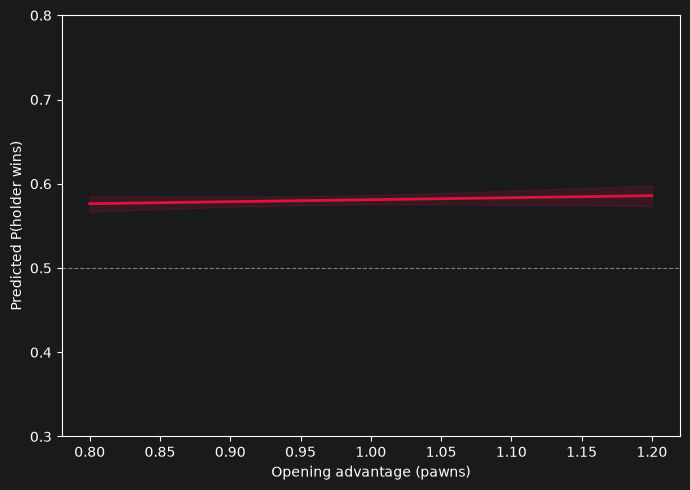

In [19]:
x_range = np.linspace(df_h1['x1_holder_eval'].min(), df_h1['x1_holder_eval'].max(), 100)
X_pred = sm.add_constant(pd.DataFrame({'x1_holder_eval': x_range}))
pred = result1.get_prediction(X_pred)
pred_df = pred.summary_frame(alpha=0.05)

# flip: predicted = P(lose), so 1 - predicted = P(win)
win_prob = 1 - pred_df['predicted']
win_ci_lower = 1 - pred_df['ci_upper']   # note: bounds swap when you invert
win_ci_upper = 1 - pred_df['ci_lower']

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_range, win_prob, color='crimson', linewidth=2)
ax.fill_between(x_range, win_ci_lower, win_ci_upper, color='crimson', alpha=0.15)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylim(0.3, 0.8)
ax.set_xlabel('Opening advantage (pawns)')
ax.set_ylabel('Predicted P(holder wins)')
plt.tight_layout()

The graph shows a flat line, which means that there is no correlation between X and Y in this database. You can get any database of games analyzed and see if this hypothesis hold.

In [20]:
print(result1.summary())
print("Pseudo-R²:", result1.prsquared)
print("Odds ratio:", np.exp(result1.params))
print("95% CI odds ratio:\n", np.exp(result1.conf_int()))

                           Logit Regression Results                           
Dep. Variable:       y_holder_outcome   No. Observations:                31190
Model:                          Logit   Df Residuals:                    31188
Method:                           MLE   Df Model:                            1
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:               2.340e-05
Time:                        20:56:54   Log-Likelihood:                -21216.
converged:                       True   LL-Null:                       -21216.
Covariance Type:            nonrobust   LLR p-value:                    0.3190
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2296      0.095     -2.414      0.016      -0.416      -0.043
x1_holder_eval    -0.0977      0.098     -0.996      0.319      -0.290       0.094
Pseudo-R²: 2.3404737173327028e-05
Od

The statsmodel summary shows what we expected, a very low Pseudo-R² (essentially zero, meaning that the predictor (opening advantage size) explains almost none of the variation in who wins. LLR p-value = 0.319, this means: even the tiny improvement this model shows over the null isn't reliable — we can't even confidently say this model beats random guessing. Again, we can get other sets of data to see if this results holds.

Building the features of the second and third hypothesis: 2: Games are decided more by large mid/late-game evaluation swings than by opening edges. 3: Blunder frequency and magnitude correlate more strongly with outcome than the opening evaluation does.

In [21]:
def build_h2h3_features(df):
    """
    H2/H3: Do eval swings and blunders predict who loses,
    regardless of opening position?
    """
    df = df.copy()
    mask = df['result'] != '1/2-1/2'
    df = df[mask].reset_index(drop=True)

    df['x1_eval_swing'] = df['largest_swing']  # already signed correctly, no np.where needed

    # x2: blunder differential, White's perspective (+ = Black blundered more, good for White)
    df['x2_blunder_diff'] = df['num_blunders_black'] - df['num_blunders_white']
    df['x2_white_blunders'] = df['num_blunders_white']
    df['x2_black_blunders'] = df['num_blunders_black']

    # y: White's outcome, 0 = won, 1 = lost
    df['y_white_outcome'] = np.where(df['result'] == '1-0', 0, 1)

    cols = ['x1_eval_swing', 'x2_blunder_diff', 'x2_white_blunders', 'x2_black_blunders',
            'y_white_outcome']
    out = df[cols].dropna().reset_index(drop=True)
    return out

fitting H2/H3 hypothesis

In [22]:
df_h2h3 = build_h2h3_features(df)

# standardize continuous predictors
df_std = df_h2h3.copy()
for c in ['x1_eval_swing', 'x2_blunder_diff']:
    df_std[c] = (df_std[c] - df_std[c].mean()) / df_std[c].std()

y = df_std['y_white_outcome']

# m2: eval swing alone
X_swing = sm.add_constant(df_std[['x1_eval_swing']])
m_swing = sm.Logit(y, X_swing).fit()

# m3: swing + blunder differential
X_full = sm.add_constant(df_std[['x1_eval_swing', 'x2_blunder_diff']])
m_full = sm.Logit(y, X_full).fit()

for name, m in [('Swing only', m_swing), ('Swing + blunders', m_full)]:
    print(f"{name}: pseudo-R²={m.prsquared:.4f}  LLR p={m.llr_pvalue:.4g}  AIC={m.aic:.1f}")

Optimization terminated successfully.
         Current function value: 0.533421
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.294620
         Iterations 7
Swing only: pseudo-R²=0.2300  LLR p=0  AIC=43721.0
Swing + blunders: pseudo-R²=0.5747  LLR p=0  AIC=24151.8


Checking VIF (Variance Inflation Factor) checks whether the predictors are too correlated with each other to trust their individual coefficients — a problem called multicollinearity.

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = X_full.drop(columns='const')
vif = pd.DataFrame({
    'feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
})
print(vif)

           feature       VIF
0    x1_eval_swing  1.127632
1  x2_blunder_diff  1.127632


Both predictors came back at ~ 1.13 — right at the "no meaningful correlation" end of the scale.

In [23]:
print(m_full.summary())
print("Odds ratios:\n", np.exp(m_full.params))
print("95% CI odds ratio:\n", np.exp(m_full.conf_int()))

                           Logit Regression Results                           
Dep. Variable:        y_white_outcome   No. Observations:                40978
Model:                          Logit   Df Residuals:                    40975
Method:                           MLE   Df Model:                            2
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:                  0.5747
Time:                        21:16:35   Log-Likelihood:                -12073.
converged:                       True   LL-Null:                       -28387.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.1145      0.016     -6.941      0.000      -0.147      -0.082
x1_eval_swing      -1.2270      0.020    -61.026      0.000      -1.266      -1.188
x2_blunder_diff    -2.7231      

#### Final results of H2/H3
First : x1_eval_swing (OR = 0.293, 95% CI [0.282, 0.305]): For each 1-standard-deviation increase in eval swing toward White, White's odds of losing are multiplied by 0.293 — roughly a 70% reduction in the odds of losing. The CI is tight and entirely below 1, so this is a strong, statistically reliable effect in the expected direction (swings favoring White make White much less likely to lose).

second: x2_blunder_diff (OR = 0.066, 95% CI [0.062, 0.069]): For each 1-SD increase in blunder differential (more Black blunders relative to White), White's odds of losing are multiplied by 0.066 — roughly a 93% reduction. This is the larger of the two effects, and it's the more dramatic number in your whole report: holding eval swing constant, blunder differential alone nearly eliminates White's losing odds as it moves in White's favor.

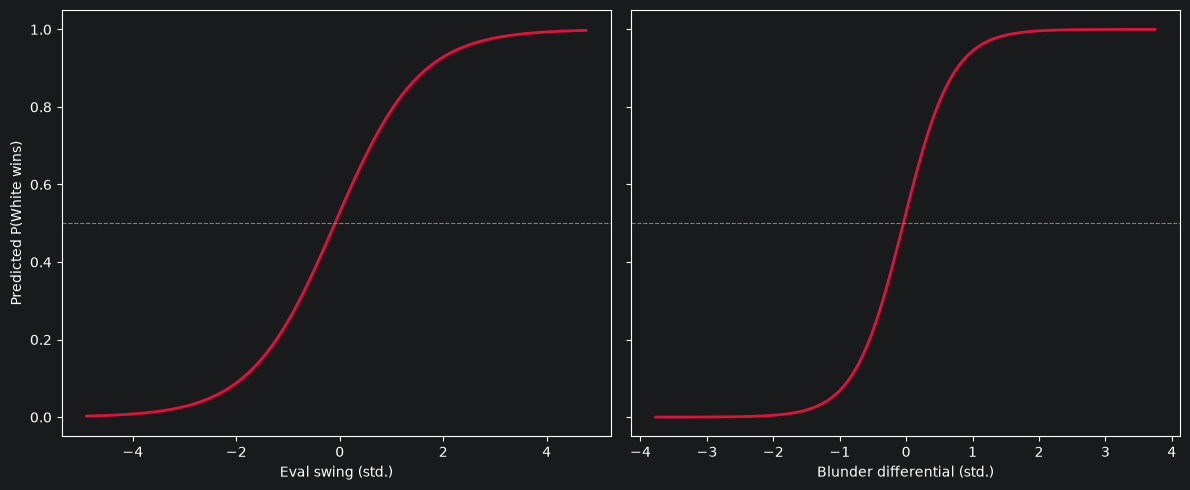

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, xcol, xlabel in zip(axes,
                              ['x1_eval_swing', 'x2_blunder_diff'],
                              ['Eval swing (std.)', 'Blunder differential (std.)']):
    other = 'x2_blunder_diff' if xcol == 'x1_eval_swing' else 'x1_eval_swing'
    x_range = np.linspace(df_std[xcol].min(), df_std[xcol].max(), 100)
    X_pred = sm.add_constant(pd.DataFrame({xcol: x_range, other: 0}))
    if xcol != 'x1_eval_swing':
        X_pred = X_pred[['const', 'x1_eval_swing', 'x2_blunder_diff']]  # match column order
    pred = m_full.get_prediction(X_pred).summary_frame(alpha=0.05)

    ax.plot(x_range, 1 - pred['predicted'], color='crimson', linewidth=2)
    ax.fill_between(x_range, 1 - pred['ci_upper'], 1 - pred['ci_lower'], color='crimson', alpha=0.15)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(xlabel)

axes[0].set_ylabel('Predicted P(White wins)')
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / "h2h3_swing_bLunder_effects.png",
            dpi=300, bbox_inches="tight")